In [1]:
import sys
sys.path.append("/home/jiahuang/test-code-hazel/")
import gen_fxns
from plot_pca import plot_pca_loadings
import h5py
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import scipy as sp
import sklearn
from datetime import date
import pandas as pd 
from datetime import timedelta
from scipy.stats import zscore
import seaborn as sns 
import pickle 
import os 
from datetime import datetime

from scipy.signal import welch
import pandas as pd
from fooof import FOOOF, FOOOFGroup
from fooof.bands import Bands
from fooof.analysis import get_band_peak_fm, get_band_peak_fg

/tmp/ipykernel_602133/2426869506.py:22: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF, FOOOFGroup


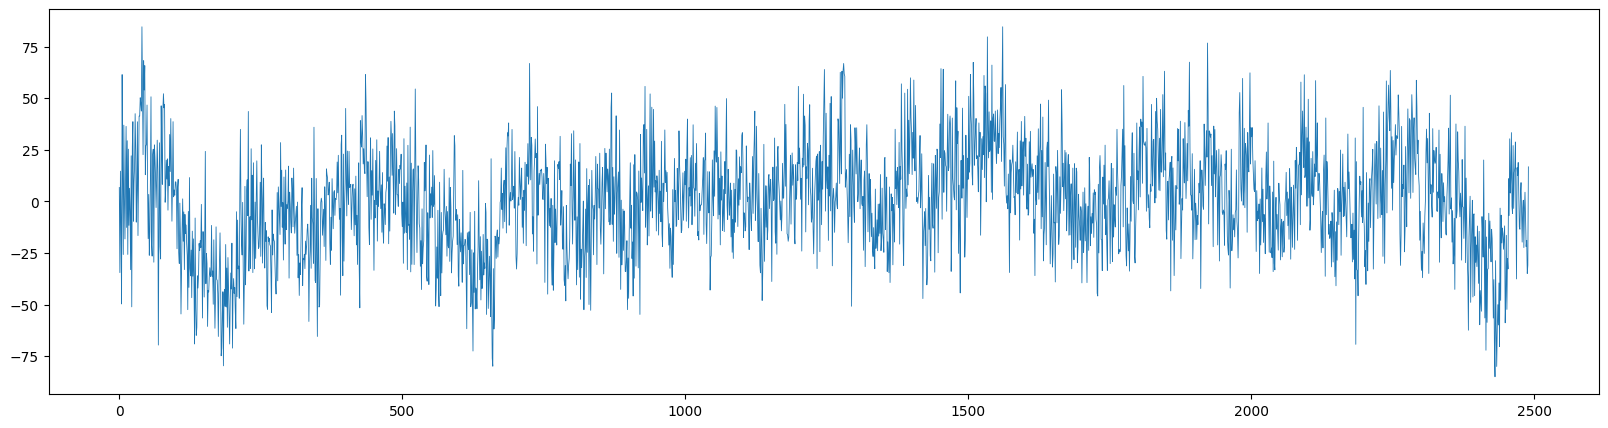

In [3]:
# Sanity check
from scipy.signal import welch

ptID = 'RCS06'
path_string = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/biomarker/preproc_data/202605_newpreproc_all_channels/"
test_file = os.path.join(path_string,"97_reref.h5")
srate_new = 1000
freqs_welch = []
freq_range = [3,70]
with h5py.File(test_file, 'r') as hf:
    # Load the dataset as float32
    dataset = np.array(hf['re-referenced'], dtype=np.float32)
rmcc = dataset[::100,18]
plt.figure(figsize=(20,5))
plt.plot(rmcc,lw=0.6)
# plt.title("RCS06 R MCC_1 rereferenced data trial 97")

# fm = FOOOF(peak_width_limits=[1, 8], min_peak_height=0.1, 
#     max_n_peaks=6, verbose=False)

# freqs_welch, psd_welch = welch(rmcc,fs=srate_new,nperseg=4 * srate_new)

(1.0, 70.0)

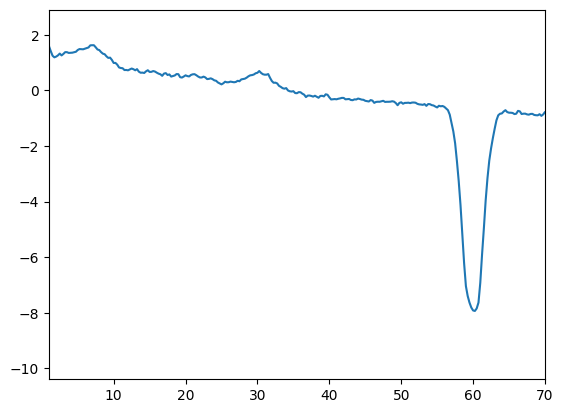

In [8]:
plt.plot(freqs_welch,np.log10(psd_welch))
plt.xlim((1,70))

In [2]:
from scipy.signal import welch

from sklearn.decomposition import PCA

ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07','RCS08','RCS09']
# ptID = 'RCS07'
# path_string = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/biomarker/preproc_data/202605_newpreproc_all_channels/"
# pt_path = f"/userdata/rvatsyayan/AnushaData/HDF5 Pain Data/{ptID}"
# # pt_path = f"/home/rvatsyayan/AnushaData"
# electrode_df = pd.read_csv(f"/home/jiahuang/test-code-hazel/{ptID}_new_electrode_property_df_updated072026.csv")
# data_root = Path(path_string)
# file_keyword = '_meanpsd_clean'
# file_keyword = '_reref'
# dataset_name = "re-referenced" # files with mean power spectral density 
# file_keyword = 'meanpsd_clean'
# dataset_name = 'mean_psd'
srate_new = 1000
freqs_welch = []
freq_range = [3,50]

# electrode_df = pd.read_csv(f"/home/jiahuang/test-code-hazel/{ptID}_new_electrode_property_df.csv")

def idx_to_channel(all_channel_labels,idx):
    match = all_channel_labels[all_channel_labels['edf_ch_idx'] == idx]
    return match['New ROI Label_all channel'].values[0]

# Function to extract numeric part from filename
def extract_number(filename):
    return int(''.join(filter(str.isdigit, filename)))
def man_z_score(array):
        array_mean = np.nanmean(array)
        array_std = np.nanstd(array)
        zscore_array = (array - array_mean)/array_std
        return zscore_array
# split trials
def split_dep(X, percent):
    idx = np.argsort(X)
    x = len(X)
    low, neutral, high = idx[:int(x*percent)], idx[int(x*percent):int(x*(1-percent))],idx[int(x*(1-percent)):]
    return high, neutral, low

def load_h5_file(path_string, pt_path, file_keyword='meanpsd', dataset_name='mean_psd'):
    h5_arrays = []
    fileids = [] 
    # Get list of files in directory and sort them based on numeric part
    files = sorted(os.listdir(path_string), key=extract_number)
    
    for filename in files:
        if filename.endswith(rf'{file_keyword}.h5'):
            filepath = os.path.join(path_string, filename)
            # Load the .h5 file
            with h5py.File(filepath, 'r') as hf:
                # Load the dataset as float32
                dataset = np.array(hf[dataset_name], dtype=np.float32)
                # Append the dataset to the list
                h5_arrays.append(dataset)

    files = sorted(os.listdir(pt_path), key=extract_number)
    for filename in files:
        if filename.endswith('.h5'):
            with h5py.File(os.path.join(pt_path, filename), 'r') as hf:
                # get record_id 
                fileid_pre = (pd.DataFrame(hf['pain_info']).iloc[1,0]).decode('utf-8')
                fileid = datetime.strptime(fileid_pre, '%d-%b-%Y %H:%M:%S')
                fileids.append(fileid)
    fileids = pd.to_datetime(fileids)

    return h5_arrays, fileids

def load_reref_file_welch(path_string, pt_path, ptID, file_keyword='reref', dataset_name='re-referenced'):
    records = []
    # Get list of files in directory and sort them based on numeric part
    files = sorted(os.listdir(path_string), key=extract_number)
    trial_idx = 0

    new_surveys,idx_to_keep,missing_channels = get_missing_trial_and_channel(path_string, pt_path, ptID)
    mask_valid, affective_latent, sensory_latent, onlyhigh_aff, onlyhigh_sens = process_score(path_string,pt_path,ptID)
    new_surveys = new_surveys.loc[mask_valid,:]
    all_channel_labels = get_all_channel_labels(path_string, pt_path, ptID)

    valid_file_indices = np.where(idx_to_keep)[0]
    valid_after_second_filter = valid_file_indices[mask_valid]
    file_to_clean = {file_idx: clean_idx for clean_idx, file_idx in enumerate(valid_after_second_filter)}


    for filename in files:
        if filename.endswith(rf'{file_keyword}.h5'):
        
            if trial_idx not in valid_after_second_filter: 
                trial_idx+=1
                continue 
            clean_idx = file_to_clean[trial_idx]

            filepath = os.path.join(path_string, filename)
            # Load the .h5 file
            with h5py.File(filepath, 'r') as hf:
                # Load the dataset as float32
                dataset = np.array(hf[dataset_name], dtype=np.float32)
                # Append the dataset to the list
                for row in all_channel_labels.itertuples(index=False):
                    fm = FOOOF(peak_width_limits=[1, 8], min_peak_height=0.1, 
                                max_n_peaks=6, verbose=False)
                    
                    ch_name = row.New_ROI_Label_all_channel
                    ch_idx = row.edf_ch_idx
                    freqs_welch, psd_welch = welch(
                        dataset[:,ch_idx], 
                        fs=srate_new,
                        nperseg=4 * srate_new
                    )

                    
                    fm.fit(freqs_welch, psd_welch, freq_range)
                    
                    group = ''
                    if clean_idx in onlyhigh_aff: group = 'only_high_aff'
                    elif clean_idx in onlyhigh_sens: group = 'only_high_sense'

                    # Append the dataset to the list
                    records.append({
                        'trial_idx': trial_idx,
                        'edf_ch_idx': ch_idx,
                        'ch_label': ch_name,
                        'psd_after_welch': psd_welch,
                        'fooof': fm,
                        'affective': affective_latent[clean_idx],
                        'sensory': sensory_latent[clean_idx],
                        'group': group
                    })
                        
                trial_idx+=1

    return pd.DataFrame(records)

def get_missing_trial_and_channel(path_string, pt_path,ptID):
    h5_arrays, fileids = load_h5_file(path_string, pt_path)
    all_data  = []
    all_data = np.stack(h5_arrays, axis=2)
    del h5_arrays

    # %%
    file = f"/home/rvatsyayan/AnushaData/Pain_Scores_{ptID}.xlsx"
    raw_surveys = pd.read_excel(file)
    
    missing_bm_data = np.setdiff1d(raw_surveys.Timestamp, fileids)
    missing_surveys = np.setdiff1d(fileids, raw_surveys.Timestamp)
    missing_channels = [i for i in range(all_data.shape[1]) if np.any(all_data[:,i,:])!=0]
    
    idx_missing_surveys = ~np.isin(fileids, missing_surveys)

    new_alldata = all_data[:,:,idx_missing_surveys]

    idx_missing_neuraldata = ~np.isin(raw_surveys.Timestamp, missing_bm_data)
    new_surveys = raw_surveys.iloc[idx_missing_neuraldata]
    assert(new_surveys.shape[0] == new_alldata.shape[2])

    return new_surveys,idx_missing_surveys,missing_channels

def get_all_channel_labels(path_string, pt_path,ptID):
    new_surveys,idx_to_keep,missing_channels = get_missing_trial_and_channel(path_string,pt_path,ptID)
    electrode_df = pd.read_csv(f"/home/jiahuang/test-code-hazel/{ptID}_new_electrode_property_df_updated072026.csv")
    electrode_df["edf_ch_idx"] = (
        electrode_df["EDF Channel Number"]
        # .astype(str)
        # .str.replace(r"[^\d]", "", regex=True)
        # .astype(int)
        - 1
    )
    electrode_df_idx = [i for i in range(electrode_df.shape[0]) if str(electrode_df['New ROI Label Hazel'][i])!='nan']
    sorted_electrode_df = electrode_df.iloc[electrode_df_idx].sort_values('New ROI Label Hazel')
    save_idx_sorted = sorted_electrode_df['edf_ch_idx'].to_numpy()
    save_idx_sorted_clean = np.array([i for i in save_idx_sorted if i in missing_channels])
    electrode_df_clean = electrode_df[electrode_df["edf_ch_idx"].isin(save_idx_sorted_clean)]
    electrode_df_clean = (
        electrode_df_clean
        .set_index("edf_ch_idx")
        .loc[save_idx_sorted_clean]
        .reset_index()
    )

    all_channel_labels = pd.DataFrame({
        'New_ROI_Label_all_channel': (electrode_df_clean["New ROI Label Hazel"].astype(str) + "_" + electrode_df_clean.groupby("New ROI Label Hazel").cumcount().add(1).astype(str)).tolist(),
        'edf_ch_idx': electrode_df_clean['edf_ch_idx']
    })
    print(all_channel_labels)
    return all_channel_labels

def process_score(path_string, pt_path,ptID, percent=0.3):
    
    new_surveys,__,__ = get_missing_trial_and_channel(path_string,pt_path,ptID)
    
    vasp = new_surveys['intensity_vas_s0'].to_numpy()
    vasd = new_surveys['mood_vas_s0'].to_numpy() # depression/mood survey scores 
    nrs = new_surveys['nrs_s0'].to_numpy()
    unpleasantness = new_surveys['unpleasantness_vas_s0'].to_numpy()
    mpq_somatic = new_surveys.iloc[:,7:18]
    mpq_affective = new_surveys[['tiring_exhausting_s0', 'sickening_s0', 'fearful_s0','punishing_cruel_s0']]
    sum_affective = np.sum(mpq_affective,axis=1).to_numpy()
    sum_somatic = np.sum(mpq_somatic,axis=1).to_numpy()

    vasp_vec = vasp.reshape(-1)
    vasd_vec = vasd.reshape(-1)
    nrs_vec = nrs.reshape(-1)
    sum_affective_vec = sum_affective.reshape(-1)
    sum_somatic_vec = sum_somatic.reshape(-1)
    unpleasantness_vec = unpleasantness.reshape(-1)

    if ptID == 'RCS08':
        mask_valid = (
            ~np.isnan(nrs_vec) &
            ~np.isnan(sum_affective_vec) &
            ~np.isnan(sum_somatic_vec) &
            ~np.isnan(unpleasantness_vec) &
            ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )
    elif ptID == 'RCS09':
        mask_valid = (
            ~np.isnan(nrs_vec) &
            ~np.isnan(sum_somatic_vec) &
            ~np.isnan(unpleasantness_vec) &
            ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )
    else:
        mask_valid = (
            ~np.isnan(vasd_vec) &
            ~np.isnan(nrs_vec) &
            ~np.isnan(sum_affective_vec) &
            ~np.isnan(sum_somatic_vec) &
            ~np.isnan(unpleasantness_vec) &
            ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )

    vasp_clean = vasp_vec[mask_valid]
    vasd_clean = vasd_vec[mask_valid]
    nrs_clean = nrs_vec[mask_valid]
    sum_affective_clean = sum_affective_vec[mask_valid]
    sum_somatic_clean = sum_somatic_vec[mask_valid]
    unpleasantness_clean = unpleasantness_vec[mask_valid]

    vasd_z_clean = man_z_score(vasd_clean)
    nrs_z_clean = man_z_score(nrs_clean)
    affective_z_clean = man_z_score(sum_affective_clean)
    somatic_z_clean = man_z_score(sum_somatic_clean)
    unpleasant_z_clean = man_z_score(unpleasantness_clean)
    vasp_z_clean = man_z_score(vasp_clean)


    
    if ptID == 'RCS08':

        X_sensory = np.stack([
            vasp_z_clean,
            nrs_z_clean,
            somatic_z_clean
        ], axis=1)

        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        X_affective = np.stack([
            unpleasant_z_clean,
            affective_z_clean
        ], axis=1)

        affective_pca = PCA(n_components=2)
        affective_latent = affective_pca.fit_transform(X_affective)

    elif ptID == 'RCS09':
        X_sensory = np.stack([
            vasp_z_clean,
            nrs_z_clean,
            somatic_z_clean
        ], axis=1)

        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        X_affective = np.stack([
            unpleasant_z_clean
        ], axis=1)

        affective_latent = unpleasant_z_clean.copy()


    else:
        X_sensory = np.stack([
            vasp_z_clean,
            nrs_z_clean,
            somatic_z_clean
        ], axis=1)

        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        X_affective = np.stack([
            -vasd_z_clean,
            unpleasant_z_clean,
            affective_z_clean
        ], axis=1)
        
        affective_pca = PCA(n_components=3)
        affective_latent = affective_pca.fit_transform(X_affective)



    high_pa, neu_pa, low_pa = split_dep(affective_latent, percent)
    
    high_ps, neu_ps, low_ps = split_dep(sensory_latent[:,0], percent)

    group1 = [i for i in np.arange(affective_latent.shape[0]) if i in high_pa and i not in high_ps]
    group2 = [i for i in np.arange(affective_latent.shape[0]) if i in high_ps and i not in high_pa]

    if ptID == 'RCS09':
        return mask_valid, affective_latent, sensory_latent[:,0],group1, group2
    return mask_valid, affective_latent[:,0], sensory_latent[:,0],group1, group2


In [ ]:
def get_behavior_table(path_string, pt_path, ptID, percent=0.3):
    new_surveys, idx_to_keep, missing_channels = get_missing_trial_and_channel(path_string, pt_path, ptID)

    vasp = new_surveys['intensity_vas_s0'].to_numpy()
    vasd = new_surveys['mood_vas_s0'].to_numpy()
    nrs = new_surveys['nrs_s0'].to_numpy()
    unpleasantness = new_surveys['unpleasantness_vas_s0'].to_numpy()
    mpq_somatic = new_surveys.iloc[:,7:18]
    mpq_affective = new_surveys[['tiring_exhausting_s0', 'sickening_s0', 'fearful_s0','punishing_cruel_s0']]
    sum_affective = np.sum(mpq_affective,axis=1).to_numpy()
    sum_somatic = np.sum(mpq_somatic,axis=1).to_numpy()

    vasp_vec = vasp.reshape(-1)
    vasd_vec = vasd.reshape(-1)
    nrs_vec = nrs.reshape(-1)
    sum_affective_vec = sum_affective.reshape(-1)
    sum_somatic_vec = sum_somatic.reshape(-1)
    unpleasantness_vec = unpleasantness.reshape(-1)

    if ptID == 'RCS08':
        mask_valid = (
            ~np.isnan(nrs_vec) & ~np.isnan(sum_affective_vec) & ~np.isnan(sum_somatic_vec) &
            ~np.isnan(unpleasantness_vec) & ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )
    elif ptID == 'RCS09':
        mask_valid = (
            ~np.isnan(nrs_vec) & ~np.isnan(sum_somatic_vec) &
            ~np.isnan(unpleasantness_vec) & ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )
    else:
        mask_valid = (
            ~np.isnan(vasd_vec) & ~np.isnan(nrs_vec) & ~np.isnan(sum_affective_vec) &
            ~np.isnan(sum_somatic_vec) & ~np.isnan(unpleasantness_vec) & ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )

    vasp_clean = vasp_vec[mask_valid]
    vasd_clean = vasd_vec[mask_valid]
    nrs_clean = nrs_vec[mask_valid]
    sum_affective_clean = sum_affective_vec[mask_valid]
    sum_somatic_clean = sum_somatic_vec[mask_valid]
    unpleasantness_clean = unpleasantness_vec[mask_valid]

    vasd_z_clean = man_z_score(vasd_clean)
    nrs_z_clean = man_z_score(nrs_clean)
    affective_z_clean = man_z_score(sum_affective_clean)
    somatic_z_clean = man_z_score(sum_somatic_clean)
    unpleasant_z_clean = man_z_score(unpleasantness_clean)
    vasp_z_clean = man_z_score(vasp_clean)

    if ptID == 'RCS08':
        X_sensory = np.stack([vasp_z_clean, nrs_z_clean, somatic_z_clean], axis=1)
        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        X_affective = np.stack([unpleasant_z_clean, affective_z_clean], axis=1)
        affective_pca = PCA(n_components=2)
        affective_latent = affective_pca.fit_transform(X_affective)

    elif ptID == 'RCS09':
        X_sensory = np.stack([vasp_z_clean, nrs_z_clean, somatic_z_clean], axis=1)
        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        affective_latent = unpleasant_z_clean.copy()  # 1D, 不是PCA

    else:
        X_sensory = np.stack([vasp_z_clean, nrs_z_clean, somatic_z_clean], axis=1)
        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        X_affective = np.stack([-vasd_z_clean, unpleasant_z_clean, affective_z_clean], axis=1)
        affective_pca = PCA(n_components=3)
        affective_latent = affective_pca.fit_transform(X_affective)

    valid_file_indices = np.where(idx_to_keep)[0]
    valid_after_second_filter = valid_file_indices[mask_valid]

    n_trial_pt = len(nrs_clean)
    assert len(valid_after_second_filter) == n_trial_pt

    pt_df = pd.DataFrame({
        'ptID': ptID,
        'trial_idx': valid_after_second_filter,

        # raw
        'nrs_raw': nrs_clean,
        'vasp_raw': vasp_clean,
        'somatic_raw': sum_somatic_clean,
        'unpleasantness_raw': unpleasantness_clean,
        'affective_raw': sum_affective_clean if ptID != 'RCS09' else np.nan,
        'vasd_raw': vasd_clean if ptID not in ['RCS08', 'RCS09'] else np.nan,

        # z-scored
        'nrs_z': nrs_z_clean,
        'vasp_z': vasp_z_clean,
        'somatic_z': somatic_z_clean,
        'unpleasantness_z': unpleasant_z_clean,
        'affective_z': affective_z_clean if ptID != 'RCS09' else np.nan,
        'vasd_r_z': -vasd_z_clean if ptID not in ['RCS08', 'RCS09'] else np.nan,  # 已reverse (-vasd)

        'pca_sensory_PC1': sensory_latent[:, 0]
    })

    if ptID == 'RCS09':
        pt_df['pca_affective_PC1'] = affective_latent
    elif ptID == 'RCS08':
        pt_df['pca_affective_PC1'] = affective_latent[:, 0]
    else:
        pt_df['pca_affective_PC1'] = affective_latent[:, 0]

    return pt_df

behavior_table_list = []

for ptID in ptIDs:
    path_string = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/biomarker/preproc_data/202605_newpreproc_all_channels/"
    pt_path = f"/userdata/rvatsyayan/AnushaData/HDF5 Pain Data/{ptID}"

    pt_df = get_behavior_table(path_string, pt_path, ptID)
    behavior_table_list.append(pt_df)

behavior_table = pd.concat(behavior_table_list, ignore_index=True)


In [11]:
def extract_fooof_params(records_df):
    exponents, offsets, r2s = [], [], []
    cfs, pws, bws = [], [], []
    
    for fm in records_df['fooof']:
        if not fm.has_model:
            exponents.append(np.nan)
            offsets.append(np.nan)
            r2s.append(np.nan)
            cfs.append(np.nan)
            pws.append(np.nan)
            bws.append(np.nan)
            continue
            
        exponents.append(fm.get_params('aperiodic_params', 'exponent'))
        offsets.append(fm.get_params('aperiodic_params', 'offset'))
        r2s.append(fm.get_params('r_squared'))
        
        peaks = fm.get_params('peak_params')
        alpha_peak = None
        if peaks.ndim == 2:
            for peak in peaks:
                if 8 <= peak[0] <= 12:
                    alpha_peak = peak
                    break
        elif peaks.ndim == 1 and len(peaks) == 3 and 8 <= peaks[0] <= 12:
            alpha_peak = peaks
            
        cfs.append(alpha_peak[0] if alpha_peak is not None else np.nan)
        pws.append(alpha_peak[1] if alpha_peak is not None else np.nan)
        bws.append(alpha_peak[2] if alpha_peak is not None else np.nan)
    
    records_df = records_df.copy()
    records_df['exponent'] = exponents
    records_df['offset'] = offsets
    records_df['r2'] = r2s
    records_df['alpha_cf'] = cfs
    records_df['alpha_pw'] = pws
    records_df['alpha_bw'] = bws
    return records_df

import pickle
ptIDs = ['RCS08']
for ptID in ptIDs:
    path_string = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/biomarker/preproc_data/202605_newpreproc_all_channels/"
    pt_path = f"/userdata/rvatsyayan/AnushaData/HDF5 Pain Data/{ptID}"
    # pt_path = f"/home/rvatsyayan/AnushaData"
    # electrode_df = pd.read_csv(f"/home/jiahuang/test-code-hazel/{ptID}_new_electrode_property_df_updated072026.csv")
    records = load_reref_file_welch(path_string, pt_path, ptID)
    records_df = extract_fooof_params(records)
    print(f"Failed fits: {records_df['exponent'].isna().sum()} / {len(records_df)}")


    save_path = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl"
    records_df.to_pickle(save_path)
    print(f"Saved to {save_path}")

/tmp/ipykernel_3113042/424351619.py:31: RuntimeWarning: Mean of empty slice
  array_mean = np.nanmean(array)
/userdata/jiahuang/myenv/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


   New_ROI_Label_all_channel  edf_ch_idx
0                L Caudate_1         111
1                L Caudate_2         112
2                     L IC_1         128
3                     L IC_2         114
4                     L IC_3         115
..                       ...         ...
59                 R dmPFC_1          54
60                 R dmPFC_2          21
61                 R dmPFC_3          20
62                 R dmPFC_4          19
63                 R dmPFC_5          18

[64 rows x 2 columns]
Failed fits: 0 / 3072
Saved to /userdata/jiahuang/pain-data/Stage1-test/RCS08/records_df_fooof_RCS08.pkl


In [6]:
def rsquared_and_N(records_df, roi, group_label, r2_threshold=0.9):
    subset = records_df[
        (records_df['roi'] == roi) & 
        (records_df['group'] == group_label)
    ]
    n_trial = len(subset['trial_idx'].unique())
    n_total = len(subset)
    subset_filtered = subset[subset['r2'] >= r2_threshold]
    n_kept = len(subset_filtered)
    
    if n_kept == 0:
        print(rf"channel_total = {n_total}, channel_kept_r2 = {n_kept}, group_label={group_label}, n_trial = {n_trial}")
        return None
    
    fm_list = subset_filtered['fooof'].tolist()
    fg = FOOOFGroup()
    fg.add_settings(fm_list[0].get_settings())
    fg.group_results = [fm.get_results() for fm in fm_list]
    print(rf"channel_total = {n_total}, channel_kept_r2 = {n_kept}, group_label={group_label}, n_trial = {n_trial}")
    return fg

# ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS08','RCS09']
ptIDs = ['RCS07']
for ptID in ptIDs:
    print(ptID)
    record_path = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl"
   
    records_df = pd.read_pickle(record_path)
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    rois = sorted(records_df['roi'].unique())
    for roi in rois:
        print(roi)
        fg_aff  = rsquared_and_N(records_df, roi, 'only_high_aff')
        fg_sens = rsquared_and_N(records_df, roi, 'only_high_sense')
        fg_neu  = rsquared_and_N(records_df, roi, '')

RCS07
L ACC
channel_total = 0, channel_kept_r2 = 0, group_label=only_high_aff, n_trial = 0
channel_total = 65, channel_kept_r2 = 65, group_label=only_high_sense, n_trial = 13
channel_total = 200, channel_kept_r2 = 200, group_label=, n_trial = 40
L AINS
channel_total = 0, channel_kept_r2 = 0, group_label=only_high_aff, n_trial = 0
channel_total = 13, channel_kept_r2 = 13, group_label=only_high_sense, n_trial = 13
channel_total = 40, channel_kept_r2 = 40, group_label=, n_trial = 40
L Caudate
channel_total = 0, channel_kept_r2 = 0, group_label=only_high_aff, n_trial = 0
channel_total = 13, channel_kept_r2 = 13, group_label=only_high_sense, n_trial = 13
channel_total = 40, channel_kept_r2 = 40, group_label=, n_trial = 40
L IC
channel_total = 0, channel_kept_r2 = 0, group_label=only_high_aff, n_trial = 0
channel_total = 39, channel_kept_r2 = 39, group_label=only_high_sense, n_trial = 13
channel_total = 120, channel_kept_r2 = 120, group_label=, n_trial = 40
L MCC
channel_total = 0, channel_k

In [ ]:
def rsquared_and_N(records_df, roi, group_label, r2_threshold=0.9):
    subset = records_df[
        (records_df['roi'] == roi) & 
        (records_df['group'] == group_label)
    ]
    n_trial = len(subset['trial_idx'].unique())
    n_total = len(subset)
    subset_filtered = subset[(subset['r2'] >= r2_threshold) & (subset['r2_high_gamma']>= r2_threshold)]
    n_kept = len(subset_filtered)
    
    if n_kept == 0:
        print(rf"channel_total = {n_total}, channel_kept_r2 = {n_kept}, group_label={group_label}, n_trial = {n_trial}")
        return None
    
    fm_list = subset_filtered['fooof'].tolist()
    fg = FOOOFGroup()
    fg.add_settings(fm_list[0].get_settings())
    fg.group_results = [fm.get_results() for fm in fm_list]
    print(rf"channel_total = {n_total}, channel_kept_r2 = {n_kept}, group_label={group_label}, n_trial = {n_trial}")
    return fg

ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS08','RCS09']
for ptID in ptIDs:
    print(ptID)
    record_path = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_with_high_gamma_{ptID}.pkl"
   
    records_df = pd.read_pickle(record_path)
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    records_df['r2_high_gamma'] = records_df['fooof_high_gamma'].apply(lambda fm: fm.get_params('r_squared'))
    
    rois = sorted(records_df['roi'].unique())

    for roi in rois:
        print(f"\n  ROI: {roi}")
        
        fg_aff  = rsquared_and_N(records_df, roi, 'only_high_aff')
        fg_sens = rsquared_and_N(records_df, roi, 'only_high_sense')
        fg_neu  = rsquared_and_N(records_df, roi, '')

In [ ]:
from scipy.stats import mannwhitneyu
from itertools import combinations

def add_significance(ax, x1, x2, y, p, h=0.02):
    if p < 0.001:   sig = '***'
    elif p < 0.01:  sig = '**'
    elif p < 0.05:  sig = '*'
    else:           return 
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, x2], lw=1, color='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom', fontsize=9)

groups = ['only_high_aff', 'only_high_sense']
colors = ['#E74C3C', '#3498DB', '#95A5A6']
labels = ['High Affective', 'High Sensory', 'Neutral']


ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS08','RCS09']
for ptID in ptIDs:
    record_path = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl"
   
    records_df = pd.read_pickle(record_path)
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    fm = records_df['fooof']
    
    
    rois = sorted(records_df['roi'].unique())
    rois_L = [r for r in rois if r.startswith('L')]
    rois_R = [r for r in rois if r.startswith('R')]
    ncols = max(len(rois_L), len(rois_R))

    fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 10), sharey=True)
    pairs = list(combinations(range(len(groups)), 2))


    for row_idx, roi_row in enumerate([rois_L, rois_R]):
        for col_idx, roi in enumerate(roi_row):
            ax = axes[row_idx, col_idx]
            roi_df = records_df[records_df['roi'] == roi]
            
            group_data = {}
            for i, (grp, clr, lab) in enumerate(zip(groups, colors, labels)):
                data = roi_df[roi_df['group'] == grp]['exponent'].dropna()
                group_data[i] = data
                if len(data) == 0:
                    continue
                ax.bar(i, data.mean(), color=clr, alpha=0.6,
                    label=lab if (row_idx==0 and col_idx==0) else '', width=0.5)
                ax.errorbar(i, data.mean(), yerr=data.sem(),
                            color='black', capsize=4, lw=1.5)
                jitter = np.random.uniform(-0.1, 0.1, len(data))
                ax.scatter(np.full(len(data), i) + jitter, data,
                        color=clr, alpha=0.5, s=15, zorder=3)

            y_max = max(d.max() for d in group_data.values() if len(d) > 0)
            step = abs(y_max) * 0.08
            for level, (i, j) in enumerate(pairs):
                d1, d2 = group_data[i], group_data[j]
                if len(d1) < 2 or len(d2) < 2:
                    continue
                _, p_raw = mannwhitneyu(d1, d2, alternative='two-sided')
                p_corrected = min(p_raw * len(pairs), 1.0)
                add_significance(ax, i, j, y_max + step*(level+1), p_corrected)

            ax.set_xticks([0, 1, 2])
            ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
            ax.set_title(roi, fontsize=10)
        
        for col_idx in range(len(roi_row), ncols):
            axes[row_idx, col_idx].set_visible(False)
    fig.suptitle(rf"{ptID} Exponent Distribution",fontsize=13)
    plt.tight_layout()

In [ ]:
from scipy.stats import mannwhitneyu
from itertools import combinations

def add_significance(ax, x1, x2, y, p, h=0.02):
    if p < 0.001:   sig = '***'
    elif p < 0.01:  sig = '**'
    elif p < 0.05:  sig = '*'
    else:           return 
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, x2], lw=1, color='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom', fontsize=9)

groups = ['only_high_aff', 'only_high_sense']
colors = ['#E74C3C', '#3498DB', '#95A5A6']
labels = ['High Affective', 'High Sensory', 'Neutral']


ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS08','RCS09']
for ptID in ptIDs:
    record_path = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl"
   
    records_df = pd.read_pickle(record_path)
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    
    rois = sorted(records_df['roi'].unique())
    rois_L = [r for r in rois if r.startswith('L')]
    rois_R = [r for r in rois if r.startswith('R')]
    ncols = max(len(rois_L), len(rois_R))

    fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 10), sharey=True)
    pairs = list(combinations(range(len(groups)), 2))


    for row_idx, roi_row in enumerate([rois_L, rois_R]):
        for col_idx, roi in enumerate(roi_row):
            ax = axes[row_idx, col_idx]
            roi_df = records_df[records_df['roi'] == roi]
            
            group_data = {}
            for i, (grp, clr, lab) in enumerate(zip(groups, colors, labels)):
                data = roi_df[roi_df['group'] == grp]['exponent'].dropna()
                group_data[i] = data
                if len(data) == 0:
                    continue
                ax.bar(i, data.mean(), color=clr, alpha=0.6,
                    label=lab if (row_idx==0 and col_idx==0) else '', width=0.5)
                ax.errorbar(i, data.mean(), yerr=data.sem(),
                            color='black', capsize=4, lw=1.5)
                jitter = np.random.uniform(-0.1, 0.1, len(data))
                ax.scatter(np.full(len(data), i) + jitter, data,
                        color=clr, alpha=0.5, s=15, zorder=3)

            y_max = max(d.max() for d in group_data.values() if len(d) > 0)
            step = abs(y_max) * 0.08
            for level, (i, j) in enumerate(pairs):
                d1, d2 = group_data[i], group_data[j]
                if len(d1) < 2 or len(d2) < 2:
                    continue
                _, p_raw = mannwhitneyu(d1, d2, alternative='two-sided')
                p_corrected = min(p_raw * len(pairs), 1.0)
                add_significance(ax, i, j, y_max + step*(level+1), p_corrected)

            ax.set_xticks([0, 1, 2])
            ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
            ax.set_title(roi, fontsize=10)
        
        for col_idx in range(len(roi_row), ncols):
            axes[row_idx, col_idx].set_visible(False)
    fig.suptitle(rf"{ptID} Exponent Distribution",fontsize=13)
    plt.tight_layout()

In [4]:
from fooof import FOOOFGroup
from fooof.bands import Bands
from fooof.analysis import get_band_peak_fg

# Import simulation utilities for making example data
from fooof.sim.gen import gen_group_power_spectra
from fooof.sim.params import param_jitter

# Import plotting function for model parameters and components
from fooof.plts.periodic import plot_peak_fits, plot_peak_params
from fooof.plts.aperiodic import plot_aperiodic_params, plot_aperiodic_fits


# Process periodic feature: extract peak in each canonical bandwith
bandref = Bands({'delta':[1,4], 
                 'theta':[4,8], 
                 'alpha':[8,12], 
                 'beta':[12,30], 
                 'low_gamma':[30,50], 
                 'high_gamma':[70,110]})

def corrected_psd(fm):
    return fm.fooofed_spectrum_ - fm._ap_fit

# example fm

ptID_example = 'RCS02'
record_path = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID_example}/records_df_fooof_with_high_gamma_{ptID_example}.pkl"

records_df = pd.read_pickle(record_path)
records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
records_df['r2_high_gamma'] = records_df['fooof_high_gamma'].apply(lambda fm: fm.get_params('r_squared'))

In [25]:
def filter_by_r2(records_df, r2_threshold=0.9):
    filtered = records_df[records_df['r2'] >= r2_threshold]
    return filtered
records_df_f = filter_by_r2(records_df)
corrected_psd = np.array([example_fm.fooofed_spectrum_ - example_fm._ap_fit for example_fm in records_df_f['fooof']])


ch_labels = records_df_f['ch_label'].unique()
trial_id = records_df_f['trial_idx'].unique()

n_ch_all = len(ch_labels)
n_trials = len(trial_id)

corrected_psd.shape, n_ch_all, n_trials

((2975, 189), 38, 81)

In [4]:
# Correlation with permutation test
def run_corr(x,y, n_freq, n_ch):
    from scipy.stats import spearmanr
    corr,p_value = spearmanr(x,y)
    correlations = corr[:-1,-1]
    p = p_value[:-1,-1].reshape(n_freq,n_ch)
    new_corr = correlations.reshape(n_freq,n_ch)
    return new_corr, p

def corr_permutation(X, Y, n_freq, n_ch, n_perm=1000):
    corr_null = np.zeros((n_perm, n_freq,n_ch))
    corr_real, __ = run_corr(X,Y,n_freq,n_ch) #return n_freq*n_ch

    for i in range(n_perm):
        Y_perm  = np.random.permutation(Y)
        null_stats, __ = run_corr(X,Y_perm, n_freq, n_ch)
        corr_null[i,:,:] = null_stats
        
    p = np.mean(np.abs(corr_null) >= np.abs(corr_real),axis=0).reshape(n_freq,n_ch)
    return corr_real, p


def basic_heatmap_onlyone(array, ch_labels, freqs, cbar_title, title, save=False, savepath=""):
    plt.figure(figsize=(16, 5))

    vmax = np.nanmax(np.abs(array))

    ax = sns.heatmap(array, cmap="RdBu_r", vmax=0.7, vmin=-vmax, center=0, cbar=True,
        xticklabels=ch_labels,
        yticklabels=freqs,
        cbar_kws={'label': cbar_title}
    )

    # missing_cols = [j for j, roi in enumerate(new_labels_bi) if roi not in list(ch_labels)]

    # for col in missing_cols:
    #     ax.add_patch(plt.Rectangle((0, col), array.shape[0],1,
    #         facecolor='lightgray',alpha=0.6,hatch='////',edgecolor='gray',
    #         linewidth=0,zorder=3
    #     ))

    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Channel")
    plt.title(title)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

    plt.tight_layout()

    if save:
        plt.savefig(f"{savepath}/{title}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [9]:
bandref = dict({'delta':[3,4], 
                 'theta':[4,8], 
                 'alpha':[8,12], 
                 'beta':[12,30], 
                 'low_gamma':[30,50], 
                 'high_gamma':[70,110]})
def plot_corr_freq_all_channel_correctedpsd(pt, savepath):
    record_path = f"/userdata/jiahuang/pain-data/Stage1-test/{pt}/records_df_fooof_{pt}.pkl"
   
    records_df = pd.read_pickle(record_path)
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    
    def filter_by_r2(records_df, r2_threshold=0.9):
        filtered = records_df[records_df['r2'] >= r2_threshold]
        return filtered

    records_df_filtered = filter_by_r2(records_df,0.9)
    
    freqs_welch = records_df_filtered['fooof'].iloc[0].freqs
    # corrected_psd = np.array([example_fm.fooofed_spectrum_ - example_fm._ap_fit for example_fm in records_df_filtered['fooof']])
    

    ch_labels = records_df_filtered['ch_label'].unique()
    trial_ids = records_df_filtered['trial_idx'].unique()
    
    n_ch_all = len(ch_labels)
    n_trials = len(trial_ids)
    n_freqs   = len(freqs_welch)
    ch_to_idx    = {c: i for i, c in enumerate(ch_labels)}
    trial_to_idx = {t: i for i, t in enumerate(trial_ids)}

    corrected_psd = np.full((n_freqs, n_ch_all, n_trials), np.nan)
    for _, row in records_df_filtered.iterrows():
        ci = ch_to_idx[row['ch_label']]
        ti = trial_to_idx[row['trial_idx']]
        corrected_psd[:, ci, ti] = row['fooof'].fooofed_spectrum_ - row['fooof']._ap_fit
            
    print(corrected_psd.shape)
    bands = list(bandref.keys())
    
    band_data = np.zeros((len(bands), n_ch_all, n_trials))

    for b in range(len(bands)):
        band = bands[b]
        (fmin, fmax) = bandref[band]
        idxf = np.where((freqs_welch >= fmin) & (freqs_welch <= fmax))[0]
        band_data[b, :, :] = np.nanmean(corrected_psd[idxf, :, :], axis=0)

    aff_score = records_df_filtered.groupby('trial_idx').first()['affective'].values
    sense_score = records_df_filtered.groupby('trial_idx').first()['sensory'].values
    
    all_data_clean_freq_z = band_data.reshape(len(bands)*len(ch_labels), n_trials).T
    print(ch_to_idx, trial_to_idx)

    corr_band, perm_p = corr_permutation(
            all_data_clean_freq_z,
            aff_score,
            len(bands),
            n_ch_all
        )
    corr_band_uncorrected = np.where(
            perm_p > 0.05,
            np.nan,
            corr_band
        )
    canonical_freq = [f"{b}\n{bandref[b][0]}-{bandref[b][1]}Hz" for b in bands]


    pd.DataFrame(corr_band_uncorrected.T, index = ch_labels, columns = canonical_freq).to_csv(f'{savepath}/{ptID}_1_over_f_corrected_PSD_Correlation_Affective.csv')
    basic_heatmap_onlyone(corr_band,ch_labels,canonical_freq,
                            'Corr', f'{pt} FOOOF Corrected PSD vs Affective PC1 Raw', False, savepath)
    basic_heatmap_onlyone(corr_band_uncorrected,ch_labels,canonical_freq,
                            'Corr', f'{pt} FOOOF Corrected PSD vs Affective PC1 Uncorrected', False, savepath)

    corr_band, perm_p = corr_permutation(
            all_data_clean_freq_z,
            sense_score,
            len(bands),
            n_ch_all
        )
    corr_band_uncorrected = np.where(
            perm_p > 0.05,
            np.nan,
            corr_band
        )
    pd.DataFrame(corr_band_uncorrected.T, index = ch_labels, columns = canonical_freq).to_csv(f'{savepath}/{ptID}_1_over_f_corrected_PSD_Correlation_Sensory.csv')
   
    canonical_freq = [f"{b}\n{bandref[b][0]}-{bandref[b][1]}Hz" for b in bands]
    basic_heatmap_onlyone(corr_band,ch_labels,canonical_freq,
                            'Corr', f'{pt} FOOOF Corrected PSD vs Sensory PC1 Raw', False, savepath)
    basic_heatmap_onlyone(corr_band_uncorrected,ch_labels,canonical_freq,
                            'Corr', f'{pt} FOOOF Corrected PSD vs Sensory PC1 Uncorrected', False, savepath)

    basic_heatmap_onlyone(np.nanmean(band_data,axis=2),ch_labels,canonical_freq,'1/f Corrected PSD','RCS02 test',False, savepath)


In [ ]:
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07','RCS08','RCS09']
for ptID in ptIDs:
    savepath = rf"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/1_over_f_no_hg"
    
    os.makedirs(savepath, exist_ok=True)

    plot_corr_freq_all_channel_correctedpsd(ptID,savepath)

In [2]:
from fooof import FOOOFGroup
from fooof.bands import Bands
from fooof.analysis import get_band_peak_fg
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
# Import simulation utilities for making example data
from fooof.sim.gen import gen_group_power_spectra
from fooof.sim.params import param_jitter

# Import plotting function for model parameters and components
from fooof.plts.periodic import plot_peak_fits, plot_peak_params
from fooof.plts.aperiodic import plot_aperiodic_params, plot_aperiodic_fits
from scipy.stats import gaussian_kde
import matplotlib.legend as mlegend

if not hasattr(mlegend.Legend, 'legendHandles'):
    mlegend.Legend.legendHandles = property(lambda self: self.legend_handles)

def fooofgroup_filter_r2(records_df, roi, group_label, r2_threshold=0.9):
    subset = records_df[
        (records_df['roi'] == roi) & 
        (records_df['group'] == group_label)
    ]
    subset_filtered = subset[subset['r2'] >= r2_threshold]
    
    fm_list = subset_filtered['fooof'].tolist()
    fg = FOOOFGroup()
    fg.add_settings(fm_list[0].get_settings())
    fg.group_results = [fm.get_results() for fm in fm_list]
    return fg
def add_significance(ax, x1, x2, y, p, h=0.02):
    if p < 0.001:   sig = '***'
    elif p < 0.01:  sig = '**'
    elif p < 0.05:  sig = '*'
    else:           return 
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y+h], lw=1, color='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom', fontsize=9)
# Process periodic feature: extract peak in each canonical bandwith
bandref = Bands({'delta':[1,4], 
                 'theta':[4,8], 
                 'alpha':[8,12], 
                 'beta':[12,30], 
                 'low_gamma':[30,50], 
                 'high_gamma':[70,115]})
# deltas = get_band_peak_fg(fg, bandref.delta) # Num group/channel * 3 (CF,PW,BW)
# thetas = get_band_peak_fg(fg, bandref.theta)
# alphas = get_band_peak_fg(fg, bandref.alpha)
# betas = get_band_peak_fg(fg, bandref.beta)
# low_gammas = get_band_peak_fg(fg, bandref.low_gamma)
# high_gammas = get_band_peak_fg(fg, bandref.high_gamma)
# groups = ['only_high_aff', 'only_high_sense', '']
# colors = ['#E74C3C', '#3498DB', '#95A5A6']
# labels = ['High Affective', 'High Sensory', 'Neutral']


# # ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS08','RCS09']
# ptID = 'RCS02'
# records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
# records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)

band_names = ['delta', 'theta', 'alpha', 'beta', 'low_gamma']
n_bands = len(band_names)

# fig, axes = plt.subplots(1, n_bands, figsize=(5*n_bands, 5), sharey=False)

# for col_idx, band in enumerate(band_names):
#     ax = axes[col_idx]
#     fmin, fmax = bandref[band]
    
#     group_data = {}
#     for grp, lab, clr in zip(groups, labels, colors):
#         subset = records_df[
#             (records_df['group'] == grp) &
#             (records_df['r2'] >= 0.9)
#         ]['fooof'].tolist()
        
#         if len(subset) == 0:
#             continue
        
#         cfs = []
#         for fm in subset:
#             try:
#                 p = fm.get_params('peak_params')
#                 if p.ndim == 2:
#                     band_peaks = p[(p[:,0] >= fmin) & (p[:,0] <= fmax)]
#                     if len(band_peaks) > 0:
#                         cfs.append(band_peaks[np.argmax(band_peaks[:,1]), 0])
#                 elif p.ndim == 1 and len(p) == 3 and fmin <= p[0] <= fmax:
#                     cfs.append(p[0])
#             except:
#                 pass
        
#         if len(cfs) == 0:
#             continue
            
#         cfs = np.array(cfs)
#         group_data[grp] = (cfs, lab, clr)
        
#         # scatter + mean
#         jitter = np.random.uniform(-0.15, 0.15, len(cfs))
#         x_pos = list(groups).index(grp)
#         ax.scatter(np.full(len(cfs), x_pos) + jitter, cfs,
#                    color=clr, alpha=0.3, s=15, zorder=2)
#         ax.errorbar(x_pos, cfs.mean(), yerr=cfs.std()/np.sqrt(len(cfs)),
#                     color=clr, capsize=5, lw=2, fmt='o', markersize=8,
#                     zorder=3, label=f"{lab} (n={len(cfs)})")

#     # significance
#     grp_keys = [g for g in groups if g in group_data]
#     pairs = list(combinations(range(len(grp_keys)), 2))
#     if len(grp_keys) >= 2:
#         y_max = max(group_data[g][0].max() for g in grp_keys)
#         step = (fmax - fmin) * 0.02
#         for level, (i, j) in enumerate(pairs):
#             g1, g2 = grp_keys[i], grp_keys[j]
#             _, p_raw = mannwhitneyu(group_data[g1][0], group_data[g2][0], alternative='two-sided')
#             p_corr = min(p_raw * len(pairs), 1.0)
#             x1, x2 = list(groups).index(g1), list(groups).index(g2)
#             add_significance(ax, x1, x2, y_max - step*(level+1), p_corr)

#     ax.set_xticks(range(len(groups)))
#     ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
#     ax.set_title(f"{band}\n{fmin}-{fmax}Hz", fontsize=10)
#     ax.set_ylabel('Peak CF (Hz)', fontsize=8)
#     ax.set_ylim(fmin - 0.5, fmax + 1.5)
#     ax.legend(fontsize=7)

# fig.suptitle(f'{ptID} - Peak CF by Band and Group', fontsize=12)
# plt.tight_layout()
# plt.show()

In [ ]:
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS08','RCS09']
groups = ['only_high_aff', 'only_high_sense']
colors = ['#E74C3C', '#3498DB']
labels = {'only_high_aff':'High Affective', 'only_high_sense':'High Sensory'}
band_names = ['delta', 'theta', 'alpha', 'beta', 'low_gamma']

result_summary = pd.DataFrame()

for ptID in ptIDs:
# ptID = 'RCS02'
    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    roi_list = sorted(records_df['roi'].unique())
    roi_colors = plt.cm.tab20(np.linspace(0, 1, len(roi_list)))
    roi_color_map = {roi: roi_colors[i] for i, roi in enumerate(roi_list)}

    n_roi = len(roi_list)
    n_band = len(band_names)

    fig, axes = plt.subplots(n_roi,n_band,figsize=(3*n_band, 4*n_roi))

    for band_idx, band in enumerate(band_names):
        fmin, fmax = bandref[band]
        for roi_idx, roi in enumerate(roi_list):
            ax = axes[roi_idx, band_idx]
            plot_rows = []
            for grp in groups:

                subset = records_df[
                    (records_df['group'] == grp) &
                    (records_df['roi'] == roi) &
                    (records_df['r2'] >= 0.9)
                ]

                for _, row in subset.iterrows():
                    try:
                        p = row['fooof'].get_params('peak_params')
                        if p.ndim == 2:
                            band_peaks = p[(p[:,0] >= fmin) & (p[:,0] <= fmax)]
                            if len(band_peaks) > 0:
                                cf = band_peaks[np.argmax(band_peaks[:,1]),0]
                                plot_rows.append({'group': labels[grp],'cf': cf})
                        elif (p.ndim == 1 and len(p) == 3 and fmin <= p[0] <= fmax):
                            plot_rows.append({'group': labels[grp], 'cf': p[0]})
                    except:
                        pass

            plot_df = pd.DataFrame(plot_rows)

            if len(plot_df) > 0:
                sns.boxplot(data = plot_df, x='group',y='cf',ax=ax,width=0.5)
                sns.stripplot(data=plot_df,x='group',y='cf',ax=ax,color='black',size=3,alpha=0.6)

            ax.set_ylim(fmin - 0.5, fmax + 1)

            if roi_idx == 0:
                ax.set_title( f'{band}\n({fmin}-{fmax} Hz)',fontsize=10)

            if band_idx == 0:
                ax.set_ylabel(roi, fontsize=9)
            else:
                ax.set_ylabel('')
            ax.set_xticks([0,1])
            ax.set_xticklabels(list(labels.values()))

            ax.tick_params(labelsize=7)

    fig.suptitle(f'{ptID} Center Frequency Distribution',fontsize=14,y=1.005)

    plt.tight_layout()
    plt.show()

/userdata/jiahuang/myenv/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/userdata/jiahuang/myenv/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/userdata/jiahuang/myenv/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/userdata/jiahuang/myenv/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/userdata/ji

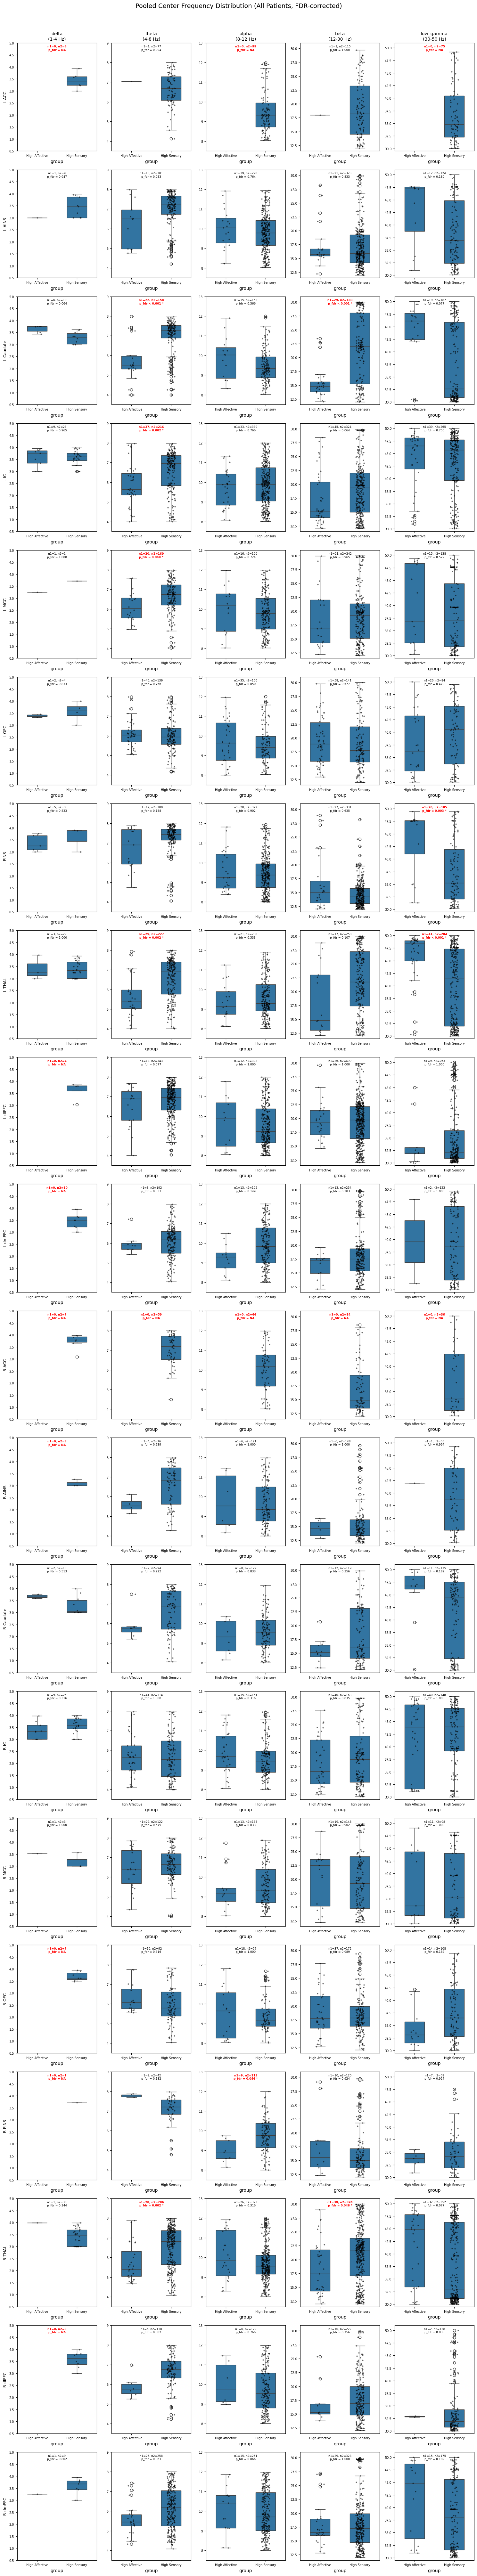

          roi       band          pval  pval_fdr  n1   n2
22  L Caudate      theta  1.644883e-05  0.000472  22  158
23       L IC      theta  1.016987e-04  0.001749  37  216
24      L MCC      theta  5.703278e-03  0.049048  20  169
27     L THAL      theta  7.199980e-05  0.001548  29  227
37     R THAL      theta  1.264545e-04  0.001813  28  286
56     R PINS      alpha  4.790621e-03  0.045777   9  113
62  L Caudate       beta  5.488997e-06  0.000236  29  183
77     R THAL       beta  4.355561e-03  0.045777  39  394
86     L PINS  low_gamma  2.520922e-04  0.003097  20  105
87     L THAL  low_gamma  6.574022e-08  0.000006  41  284


In [5]:
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS08', 'RCS09']
groups = ['only_high_aff', 'only_high_sense']
colors = ['#E74C3C', '#3498DB']
labels = {'only_high_aff': 'High Affective', 'only_high_sense': 'High Sensory'}
band_names = ['delta', 'theta', 'alpha', 'beta', 'low_gamma']

all_peak_rows = []

for ptID in ptIDs:
    if ptID == 'RCS07': continue
    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    
    for band in band_names:
        fmin, fmax = bandref[band]
        for grp in groups:
            subset = records_df[
                (records_df['group'] == grp) &
                (records_df['r2'] >= 0.9)
            ]
            
            for _, row in subset.iterrows():
                try:
                    p = row['fooof'].get_params('peak_params')
                    roi = row['roi']
                    if p.ndim == 2:
                        band_peaks = p[(p[:, 0] >= fmin) & (p[:, 0] <= fmax)]
                        if len(band_peaks) > 0:
                            cf = band_peaks[np.argmax(band_peaks[:, 1]), 0]
                            all_peak_rows.append({
                                'ptID': ptID, 'roi': roi, 'band': band,
                                'group': labels[grp], 'cf': cf
                            })
                    elif (p.ndim == 1 and len(p) == 3 and fmin <= p[0] <= fmax):
                        all_peak_rows.append({
                            'ptID': ptID, 'roi': roi, 'band': band,
                            'group': labels[grp], 'cf': p[0]
                        })
                except:
                    pass

pooled_df = pd.DataFrame(all_peak_rows)
roi_list = sorted(pooled_df['roi'].unique())
n_roi = len(roi_list)
n_band = len(band_names)
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

test_results = []

for band in band_names:
    
    for roi in roi_list:
        plot_df = pooled_df[(pooled_df['roi'] == roi) & (pooled_df['band'] == band)]
        g1 = plot_df[plot_df['group'] == labels['only_high_aff']]['cf']
        g2 = plot_df[plot_df['group'] == labels['only_high_sense']]['cf']
        
        if len(g1) > 0 and len(g2) > 0:
            stat, pval = mannwhitneyu(g1, g2, alternative='two-sided')
        else:
            pval = np.nan
        
        test_results.append({
            'roi': roi, 'band': band,
            'pval': pval, 'n1': len(g1), 'n2': len(g2)
        })

test_results_df = pd.DataFrame(test_results)

valid_mask = test_results_df['pval'].notna()
pvals_valid = test_results_df.loc[valid_mask, 'pval'].values

if len(pvals_valid) > 0:
    reject, pvals_fdr, _, _ = multipletests(pvals_valid, alpha=0.05, method='fdr_bh')
    test_results_df.loc[valid_mask, 'pval_fdr'] = pvals_fdr
    test_results_df.loc[valid_mask, 'significant'] = reject
else:
    test_results_df['pval_fdr'] = np.nan
    test_results_df['significant'] = False

fig, axes = plt.subplots(n_roi, n_band, figsize=(3 * n_band, 4 * n_roi))
if n_roi == 1:
    axes = axes.reshape(1, -1)

for band_idx, band in enumerate(band_names):
    fmin, fmax = bandref[band]
    for roi_idx, roi in enumerate(roi_list):
        ax = axes[roi_idx, band_idx]
        
        plot_df = pooled_df[(pooled_df['roi'] == roi) & (pooled_df['band'] == band)]
        
        if len(plot_df) > 0:
            sns.boxplot(data=plot_df, x='group', y='cf', ax=ax, width=0.5,
                        order=list(labels.values()))
            sns.stripplot(data=plot_df, x='group', y='cf', ax=ax,
                          color='black', size=3, alpha=0.6,
                          order=list(labels.values()))
            
            res_row = test_results_df[
                (test_results_df['roi'] == roi) & (test_results_df['band'] == band)
            ].iloc[0]
            
            n1, n2 = int(res_row['n1']), int(res_row['n2'])
            pval_fdr = res_row['pval_fdr']
            sig = res_row['significant']
            
            if not np.isnan(pval_fdr):
                p_text = f'p_fdr = {pval_fdr:.3f}' if pval_fdr >= 0.001 else 'p_fdr < 0.001'
                if sig:
                    p_text += ' *'
            else:
                p_text = 'p_fdr = NA'
            
            n_text = f'n1={n1}, n2={n2}'
            
            ax.annotate(
                f'{n_text}\n{p_text}',
                xy=(0.5, 0.98), xycoords='axes fraction',
                fontsize=6.5, ha='center', va='top',
                color='red' if sig else 'black',
                fontweight='bold' if sig else 'normal'
            )
        
        ax.set_ylim(fmin - 0.5, fmax + 1)
        
        if roi_idx == 0:
            ax.set_title(f'{band}\n({fmin}-{fmax} Hz)', fontsize=10)
        if band_idx == 0:
            ax.set_ylabel(roi, fontsize=9)
        else:
            ax.set_ylabel('')
        
        ax.set_xticks([0, 1])
        ax.set_xticklabels(list(labels.values()))
        ax.tick_params(labelsize=7)

fig.suptitle('Pooled Center Frequency Distribution (All Patients, FDR-corrected)', fontsize=14, y=1.005)
plt.tight_layout()
# plt.savefig('pooled_center_frequency_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(test_results_df[test_results_df['significant'] == True][['roi', 'band', 'pval', 'pval_fdr', 'n1', 'n2']])

In [ ]:
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07','RCS08','RCS09']
groups = ['only_high_aff', 'only_high_sense']
colors = ['#E74C3C', '#3498DB']
labels = ['High Affective', 'High Sensory']
band_names = ['delta', 'theta', 'alpha', 'beta', 'low_gamma']

result_summary = pd.DataFrame()

for ptID in ptIDs:
# ptID = 'RCS02'
    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    roi_list = sorted(records_df['roi'].unique())
    roi_colors = plt.cm.tab20(np.linspace(0, 1, len(roi_list)))
    roi_color_map = {roi: roi_colors[i] for i, roi in enumerate(roi_list)}

    fig, axes = plt.subplots(1, n_bands, figsize=(3*n_bands, 5), sharey=False)

    for col_idx, band in enumerate(band_names):
        ax = axes[col_idx]
        fmin, fmax = bandref[band]
        
        group_data_mean = {}
        cfs_per_grp = {}
        cf_rois_per_grp = {}

        pws_per_grp = {}
        pw_rois_per_grp = {}
        
        for grp, lab, clr in zip(groups, labels, colors):
            subset = records_df[
                (records_df['group'] == grp) &
                (records_df['r2'] >= 0.9)
            ][['fooof', 'roi']].copy()
            
            if len(subset) == 0:
                continue
            
            cfs, cf_rois = [], []
            pws, pw_rois = [], []
            for _, row in subset.iterrows():
                try:
                    p = row['fooof'].get_params('peak_params')
                    if p.ndim == 2:
                        band_peaks = p[(p[:,0] >= fmin) & (p[:,0] <= fmax)]
                        if len(band_peaks) > 0:
                            cfs.append(band_peaks[np.argmax(band_peaks[:,1]), 0])
                            pws.append(band_peaks[np.argmax(band_peaks[:,1]), 1])
                            cf_rois.append(row['roi'])
                            pw_rois.append(row['roi'])
                    elif p.ndim == 1 and len(p) == 3 and fmin <= p[0] <= fmax:
                        cfs.append(p[0])
                        pws.append(p[1])
                        cf_rois.append(row['roi'])
                        pw_rois.append(row['roi'])
                except:
                    pass
            
            if len(cfs) == 0:
                continue
            
            # roi_mean_series = pd.DataFrame({'roi': cf_rois, 'cf': cfs}).groupby('roi')['cf'].mean()
            # roi_count_series = pd.DataFrame({'roi': cf_rois, 'cf': cfs}).groupby('roi')['cf'].count()

            roi_mean_series = pd.DataFrame({'roi': cf_rois, 'cf': cfs, 'pw': pws}).groupby('roi')['pw'].mean()
            roi_count_series = pd.DataFrame({'roi': cf_rois, 'cf': cfs, 'pw': pws}).groupby('roi')['pw'].count()

            group_data_mean[grp] = {
                'pw':    roi_mean_series,   # Series, index=roi
                'count': roi_count_series,
                'lab':   lab,
                'clr':   clr
            }
            
            # cfs_per_grp[grp] = cfs
            # cf_rois_per_grp[grp] = cf_rois

            pws_per_grp[grp] = pws
            pw_rois_per_grp[grp] = pw_rois
            
            x_pos  = list(groups).index(grp)
            # jitter = np.random.uniform(-0.1, 0.1, len(roi_mean_series))
            
            for pw, roi in zip(roi_mean_series.values, roi_mean_series.index):
                ax.scatter(x_pos, pw,
                        color=roi_color_map.get(roi, 'gray'),
                        alpha=0.7, s=30, zorder=3)
            
            ax.errorbar(x_pos, roi_mean_series.mean(),
                        yerr=roi_mean_series.std()/np.sqrt(len(roi_mean_series)),
                        color=clr, capsize=5, lw=2, fmt='o', markersize=10,
                        markeredgecolor='black', zorder=4, label=f"{lab}")

        pair_comparisons = [
            ('only_high_aff', 'only_high_sense')
        ]
        
        roi_sig_results = {}  # roi → {pair: (p, n)}
        
        for g1, g2 in pair_comparisons:
            if g1 not in group_data_mean or g2 not in group_data_mean: continue
            pw1 = group_data_mean[g1]['pw']
            pw2 = group_data_mean[g2]['pw']
            common_rois = pw1.index.intersection(pw2.index)
            
            x1 = list(groups).index(g1)
            x2 = list(groups).index(g2)
            
            for roi in common_rois:
                ax.plot([x1, x2], [pw1[roi], pw2[roi]],
                        color=roi_color_map.get(roi, 'gray'),
                        alpha=0.4, lw=1, zorder=1)

        for g1, g2 in pair_comparisons:
            
            if g1 not in group_data_mean or g2 not in group_data_mean: continue
            df_g1 = pd.DataFrame({'roi': pw_rois_per_grp[g1], 'pw': pws_per_grp[g1]})
            df_g2 = pd.DataFrame({'roi': pw_rois_per_grp[g2], 'pw': pws_per_grp[g2]})
            
            common_rois = set(df_g1['roi'].unique()) & set(df_g2['roi'].unique())
            
            for roi in common_rois:
                v1 = df_g1[df_g1['roi'] == roi]['pw'].values
                v2 = df_g2[df_g2['roi'] == roi]['pw'].values
                
                m1 = np.nanmean(v1)
                m2 = np.nanmean(v2)
                
                _, p = mannwhitneyu(v1, v2, alternative='two-sided')
                
                pair_key = f"{g1}_vs_{g2}"
                if roi not in roi_sig_results:
                    roi_sig_results[roi] = {}
                roi_sig_results[roi][pair_key] = {
                    'p': p, 'n1': len(v1), 'n2': len(v2),
                    'aff mean': m1, 'sense mean': m2
                }
        
        rows = []
        # print(f"\n=== {ptID} {band} ({fmin}-{fmax}Hz) ===")
        for roi, pairs in roi_sig_results.items():
            for pair_key, stats in pairs.items():
                p = stats['p']
                sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
                # print(f"  {roi} | {pair_key}: p={p:.4f} {sig} (n1={stats['n1']}, n2={stats['n2']}), (m1={stats['aff mean']:.3f}, m2={stats['sense mean']:.3f})")
                
                rows.append({
                    'ptID':     ptID,
                    'band':     band,
                    'roi':      roi,
                    'pair':     pair_key,
                    'p':        p,
                    'sig':      sig,
                    'm1_aff':   stats['aff mean'],
                    'm2_sens':  stats['sense mean'],
                    'n1':       stats['n1'],
                    'n2':       stats['n2'],
                })

        result_summary = pd.concat([result_summary, pd.DataFrame(rows)], ignore_index=True)

        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
        ax.set_title(f"{band}\n{fmin}-{fmax}Hz", fontsize=10)
        ax.set_ylabel('Power', fontsize=8)
        # ax.set_ylim(fmin - 0.5, fmax + 2)

    roi_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=roi_color_map[r], markersize=8, label=r) for r in roi_list]
    fig.legend(handles=roi_handles, title='ROI', loc='lower center',
            bbox_to_anchor=(0.5, -0.05),
            ncol=len(roi_list)//2, fontsize=7)

    fig.suptitle(f'{ptID} - Power by Band and Group (ROI mean)', fontsize=12)
    plt.tight_layout()
    plt.show()

In [8]:
sig_only = result_summary[result_summary['sig'] != 'ns']

In [9]:
save_path_temp = rf'/userdata/jiahuang/pain-data/Stage1-test'

In [10]:
result_summary.groupby('roi')[['ptID', 'band', 'p', 'sig', 'm1_aff', 'm2_sens']].apply(lambda x: x.sort_values('band')).to_csv(rf"{save_path_temp}/1_over_f_periodic_pw_data.csv")

In [ ]:
result_summary.where('roi'=='').groupby('roi')[['ptID', 'band', 'p', 'sig', 'm1_aff', 'm2_sens']].apply(lambda x: x.sort_values('band'))

ptID       band         p sig    m1_aff   m2_sens
roi                                                            
L ACC   108  RCS04      alpha  0.565734  ns  0.352553  0.335016
        216  RCS06      alpha  0.573737  ns  0.247635  0.246463
        122  RCS04       beta  0.558337  ns  0.313903  0.370221
        230  RCS06       beta  0.370383  ns  0.208735  0.097432
        136  RCS04  low_gamma  0.006167  **  0.130728  0.344805
...            ...        ...       ...  ..       ...       ...
R dmPFC 55   RCS03      theta  0.291577  ns  0.500910  0.483769
        317  RCS09      theta  0.480731  ns  0.577417  0.597347
        9    RCS02      theta  0.072441  ns  0.576036  0.596454
        202  RCS06      theta  0.658843  ns  0.864529  0.900510
        149  RCS05      theta  0.918182  ns  0.306473  0.282884

[353 rows x 6 columns]

In [28]:
sig_group = sig_only.groupby('roi')[['ptID', 'band', 'p', 'sig', 'm1_aff', 'm2_sens']].apply(lambda x: x.sort_values('band'))
sig_group['difference(affective - sensory)'] = sig_group['m1_aff'] - sig_group['m2_sens']
sig_group.groupby(['band'])[['ptID', 'p', 'sig', 'difference(affective - sensory)']].apply(lambda x: x.sort_values(['difference(affective - sensory)','roi']))

ptID         p  sig  difference(affective - sensory)
band      roi                                                                 
alpha     L PINS    269  RCS08  0.002810   **                        -0.149813
          R dmPFC   271  RCS08  0.004346   **                        -0.125740
          L MCC     159  RCS05  0.031746    *                        -0.108664
          L dlPFC   268  RCS08  0.012200    *                        -0.106783
          R THAL    21   RCS02  0.013206    *                        -0.063786
          L AINS    212  RCS06  0.018495    *                        -0.058759
          R OFC     332  RCS09  0.048485    *                         0.040758
          R dlPFC   162  RCS05  0.004346   **                         0.149669
          R ACC     109  RCS04  0.003196   **                         0.159645
          L dlPFC   104  RCS04  0.007405   **                         0.393318
beta      R IC      293  RCS08  0.014397    *                        -0.211545
          R dmPFC   285  RCS08  0.000021  ***                        -0.206556
          L dlPFC   282  RCS08  0.000743  ***                        -0.151943
          R AINS    287  RCS08  0.002525   **                        -0.140914
          R THAL    290  RCS08  0.001991   **                        -0.128082
          R PINS    291  RCS08  0.043895    *                        -0.093894
          R MCC     281  RCS08  0.025525    *                        -0.058291
          R OFC     292  RCS08  0.000063  ***                        -0.054515
          R ACC     123  RCS04  0.032216    *                         0.082845
          R dlPFC   120  RCS04  0.005699   **                         0.192551
          L dmPFC   126  RCS04  0.000576  ***                         0.196140
          L dlPFC   118  RCS04  0.000032  ***                         0.405986
low_gamma R MCC     130  RCS04  0.038095    *                        -0.243256
                    35   RCS02  0.000624  ***                        -0.233959
          L ACC     136  RCS04  0.006167   **                        -0.214077
          R THAL    248  RCS06  0.043205    *                        -0.134490
                    40   RCS02  0.004022   **                        -0.111806
          L MCC     36   RCS02  0.017574    *                        -0.092103
          L Caudate 186  RCS05  0.016140    *                         0.044430
          L THAL    300  RCS08  0.008714   **                         0.065004
          L PINS    44   RCS02  0.019014    *                         0.362440
theta     L dmPFC   152  RCS05  0.007882   **                        -0.105103
          R THAL    263  RCS08  0.005795   **                        -0.085575
          L dmPFC   57   RCS03  0.044478    *                         0.047613
          L MCC     51   RCS03  0.028601    *                         0.051777
          L dlPFC   7    RCS02  0.019745    *                         0.057586
          L MCC     6    RCS02  0.013880    *                         0.093971
          R ACC     95   RCS04  0.000310  ***                         0.268178
          R dmPFC   93   RCS04  0.041126    *                         0.386230

In [28]:

ptID = 'RCS02'
path_string = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/biomarker/preproc_data/202605_newpreproc_all_channels/"
pt_path = f"/userdata/rvatsyayan/AnushaData/HDF5 Pain Data/{ptID}"
records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")

new_surveys,idx_to_keep,__ = get_missing_trial_and_channel(path_string,pt_path,ptID)
mask_valid,__,__,__,__ = process_score(path_string, pt_path,ptID, percent=0.3)

mpq_somatic = new_surveys.iloc[:,7:18]
mpq_affective = new_surveys[['tiring_exhausting_s0', 'sickening_s0', 'fearful_s0','punishing_cruel_s0']]
sum_affective = np.sum(mpq_affective,axis=1).to_numpy()
sum_somatic = np.sum(mpq_somatic,axis=1).to_numpy()
sum_affective_vec = sum_affective.reshape(-1)
sum_somatic_vec = sum_somatic.reshape(-1)
    
sum_affective_clean = sum_affective_vec[mask_valid]
sum_somatic_clean = sum_somatic_vec[mask_valid]
   
affective_z_clean = man_z_score(sum_affective_clean)
somatic_z_clean = man_z_score(sum_somatic_clean)

clean_idx_to_affective = {i: affective_z_clean[i] for i in range(len(affective_z_clean))}
clean_idx_to_somatic   = {i: somatic_z_clean[i]   for i in range(len(somatic_z_clean))}


valid_file_indices = np.where(idx_to_keep)[0]
valid_after_second_filter = valid_file_indices[mask_valid]
file_to_clean = {file_idx: clean_idx for clean_idx, file_idx in enumerate(valid_after_second_filter)}
print(file_to_clean)

# trial_idx → clean_idx → score
records_df['mpq_aff'] = records_df['trial_idx'].map(
    {trial: clean_idx_to_affective[file_to_clean[trial]] 
     for trial in records_df['trial_idx'].unique() 
     if trial in file_to_clean}
)
records_df['mpq_som'] = records_df['trial_idx'].map(
    {trial: clean_idx_to_somatic[file_to_clean[trial]]
     for trial in records_df['trial_idx'].unique()
     if trial in file_to_clean}
)

percent=0.3
high_pa, neu_pa, low_pa = split_dep(affective_z_clean, percent)

high_ps, neu_ps, low_ps = split_dep(somatic_z_clean, percent)

group1 = [i for i in np.arange(len(affective_z_clean)) if i in high_pa and i not in high_ps]
group2 = [i for i in np.arange(len(somatic_z_clean)) if i in high_ps and i not in high_pa]

def alt_group_mpq(trial_idx):
    idx = file_to_clean[trial_idx]
    if idx in group1:
        return 'only_high_mpq_aff'
    elif idx in group2:
        return 'only_high_mpq_som'
    else:
        return ''

records_df['alt_group_mpq'] = records_df['trial_idx'].apply(alt_group_mpq)

{32: 0, 33: 1, 34: 2, 35: 3, 36: 4, 37: 5, 38: 6, 39: 7, 40: 8, 41: 9, 42: 10, 43: 11, 44: 12, 45: 13, 46: 14, 47: 15, 48: 16, 49: 17, 50: 18, 51: 19, 52: 20, 54: 21, 55: 22, 56: 23, 58: 24, 60: 25, 61: 26, 62: 27, 63: 28, 64: 29, 65: 30, 66: 31, 67: 32, 68: 33, 69: 34, 70: 35, 71: 36, 72: 37, 73: 38, 74: 39, 75: 40, 76: 41, 77: 42, 78: 43, 79: 44, 80: 45, 81: 46, 82: 47, 83: 48, 84: 49, 85: 50, 86: 51, 87: 52, 88: 53, 89: 54, 91: 55, 92: 56, 93: 57, 94: 58, 95: 59, 96: 60, 97: 61, 98: 62, 99: 63, 100: 64, 101: 65, 102: 66, 103: 67, 104: 68, 105: 69, 106: 70, 108: 71, 109: 72, 110: 73, 111: 74, 112: 75, 113: 76, 114: 77, 115: 78, 116: 79, 117: 80}


only_high_mpq_aff High MPQ Affective 12
only_high_mpq_som High MPQ Somatic 11
 Neutral 67
only_high_mpq_aff High MPQ Affective 378
only_high_mpq_som High MPQ Somatic 396
 Neutral 1310
only_high_mpq_aff High MPQ Affective 387
only_high_mpq_som High MPQ Somatic 381
 Neutral 1355
only_high_mpq_aff High MPQ Affective 445
only_high_mpq_som High MPQ Somatic 428
 Neutral 1627
only_high_mpq_aff High MPQ Affective 209
only_high_mpq_som High MPQ Somatic 221
 Neutral 860


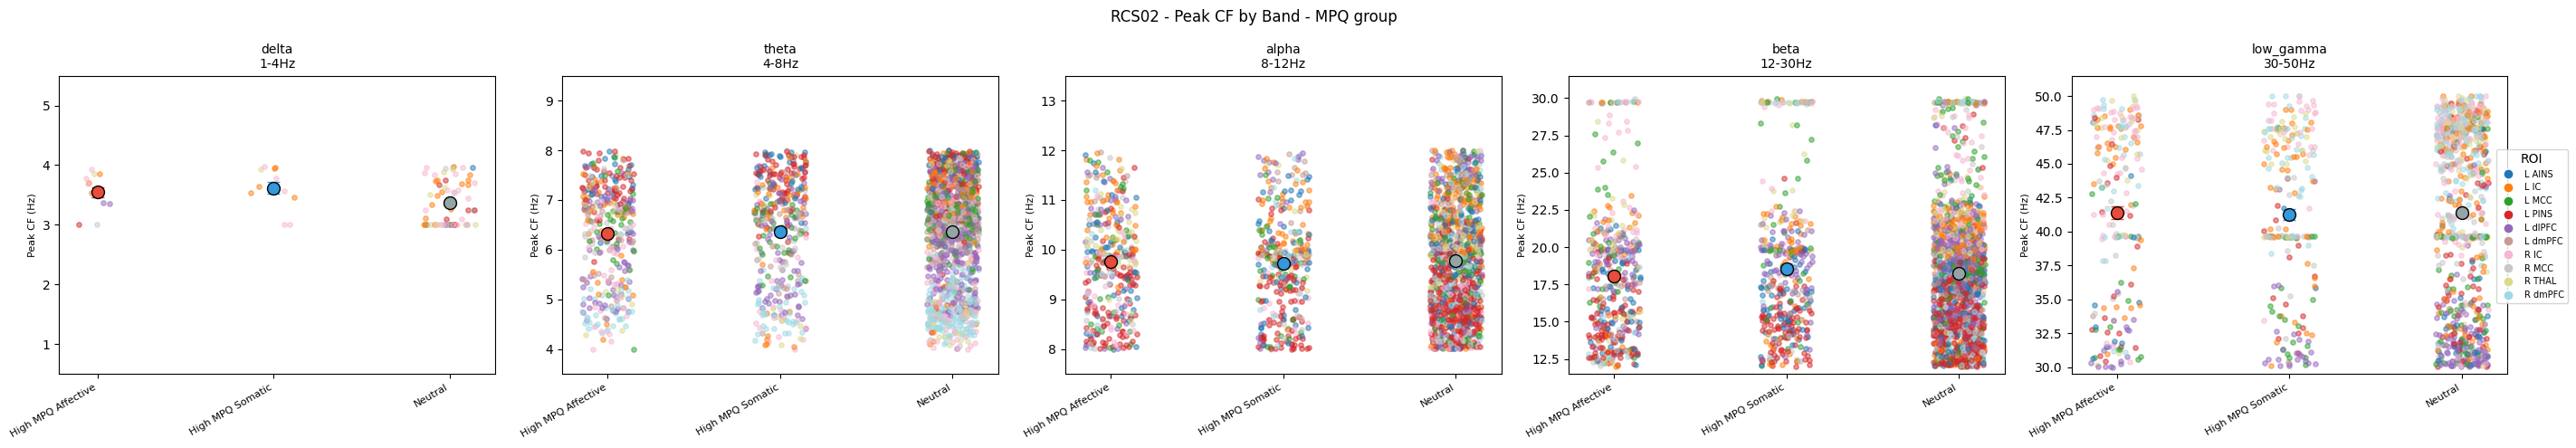

In [29]:
records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
bandref = Bands({'delta':[1,4], 
                 'theta':[4,8], 
                 'alpha':[8,12], 
                 'beta':[12,30], 
                 'low_gamma':[30,50], 
                 'high_gamma':[70,115]})

band_names = ['delta', 'theta', 'alpha', 'beta', 'low_gamma']
n_bands = len(band_names)

from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

roi_list = sorted(records_df['roi'].unique())
roi_colors = plt.cm.tab20(np.linspace(0, 1, len(roi_list)))
roi_color_map = {roi: roi_colors[i] for i, roi in enumerate(roi_list)}

fig, axes = plt.subplots(1, n_bands, figsize=(5*n_bands+3, 5), sharey=False)
groups = ['only_high_mpq_aff','only_high_mpq_som','']

colors = ['#E74C3C', '#3498DB', '#95A5A6']
labels = ['High MPQ Affective','High MPQ Somatic','Neutral']
for col_idx, band in enumerate(band_names):
    ax = axes[col_idx]
    fmin, fmax = bandref[band]
    
    group_data = {}
    for grp, lab, clr in zip(groups, labels, colors):
        subset = records_df[
            (records_df['alt_group_mpq'] == grp) &
            (records_df['r2'] >= 0.9)
        ][['fooof', 'roi']].copy()
        
        if len(subset) == 0:
            continue
        
        cfs, cf_rois = [], []
        for _, row in subset.iterrows():
            try:
                p = row['fooof'].get_params('peak_params')
                if p.ndim == 2:
                    band_peaks = p[(p[:,0] >= fmin) & (p[:,0] <= fmax)]
                    if len(band_peaks) > 0:
                        cfs.append(band_peaks[np.argmax(band_peaks[:,1]), 0])
                        cf_rois.append(row['roi'])
                elif p.ndim == 1 and len(p) == 3 and fmin <= p[0] <= fmax:
                    cfs.append(p[0])
                    cf_rois.append(row['roi'])
            except:
                pass
        
        if len(cfs) == 0:
            continue
        print(grp, lab,len(cfs))
        cfs = np.array(cfs)
        group_data[grp] = (cfs, lab, clr)
        x_pos = list(groups).index(grp)
        
        jitter = np.random.uniform(-0.15, 0.15, len(cfs))
        for cf, roi, j in zip(cfs, cf_rois, jitter):
            ax.scatter(x_pos + j, cf,
                       color=roi_color_map[roi], alpha=0.5, s=15, zorder=2)
        
        ax.errorbar(x_pos, cfs.mean(), yerr=cfs.std()/np.sqrt(len(cfs)),
                    color=clr, capsize=5, lw=2, fmt='o', markersize=10,
                    markeredgecolor='black', zorder=4, label=f"{lab} (n={len(cfs)})")

    # significance
    grp_keys = [g for g in groups if g in group_data]
    pairs = list(combinations(range(len(grp_keys)), 2))
    if len(grp_keys) >= 2:
        y_max = max(group_data[g][0].max() for g in grp_keys)
        step = (fmax - fmin) * 0.02
        for level, (i, j) in enumerate(pairs):
            g1, g2 = grp_keys[i], grp_keys[j]
            _, p_raw = mannwhitneyu(group_data[g1][0], group_data[g2][0], alternative='two-sided')
            p_corr = min(p_raw * len(pairs), 1.0)
            x1, x2 = list(groups).index(g1), list(groups).index(g2)
            add_significance(ax, x1, x2, y_max - step*(level+2), p_corr)

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_title(f"{band}\n{fmin}-{fmax}Hz", fontsize=10)
    ax.set_ylabel('Peak CF (Hz)', fontsize=8)
    ax.set_ylim(fmin - 0.5, fmax + 1.5)
    # ax.legend(fontsize=7)

roi_handles = [plt.Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=roi_color_map[r], markersize=8, label=r)
               for r in roi_list]
fig.legend(handles=roi_handles, title='ROI', loc='center right',
           bbox_to_anchor=(1.02, 0.5), fontsize=7)

fig.suptitle(f'{ptID} - Peak CF by Band - MPQ group', fontsize=12)
plt.tight_layout()
plt.show()

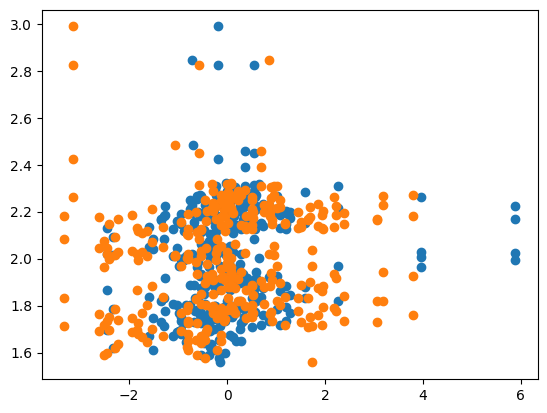

In [33]:
subset = records_df[
            (records_df['roi'] == 'L AINS') &
            (records_df['r2'] >= 0.9)
        ]
plt.scatter(subset['affective'],subset['exponent'])
# plt.scatter(subset['affective'],subset['offset'])
plt.scatter(subset['sensory'],subset['exponent'])
# plt.scatter(subset['sensory'],subset['offset'])
# r2 and p val
# per roir per patient

In [ ]:

for ptID in ptIDs:
    print(ptID)
    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    rois = sorted(records_df['roi'].unique())

    for roi in rois:
        fg_aff  = fooofgroup_from_records(records_df, roi, 'only_high_aff')
        fg_sens = fooofgroup_from_records(records_df, roi, 'only_high_sense')
        fg_neu  = fooofgroup_from_records(records_df, roi, '')
        
        alpha_peaks = []
        plot_labels = []
        plot_colors = []
        
        for fg, lab, clr in  zip([fg_aff, fg_sens, fg_neu], labels, colors) :
            peaks = get_band_peak_fg(fg, bandref.alpha)  
            
            peaks_valid = peaks[~np.isnan(peaks[:, 0])]
            if len(peaks_valid) > 0:
                alpha_peaks.append(peaks_valid)
                plot_labels.append(f"{lab} (n={len(peaks_valid)})")
                plot_colors.append(clr)
        
        fig, ax = plt.subplots(figsize=(6, 4))
        plot_peak_fits(alpha_peaks, labels=plot_labels, colors=plot_colors, ax=ax)
        ax.set_title(f"{ptID} - {roi} Alpha Peak")
        ax.set_xlabel("Frequency (Hz)")
        plt.tight_layout()
        plt.show()

In [ ]:
groups = ['only_high_aff', 'only_high_sense', '']
colors = ['#E74C3C', '#3498DB', '#95A5A6']
labels = ['High Affective', 'High Sensory', 'Neutral']


ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS08','RCS09']

for ptID in ptIDs:
    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    rois = sorted(records_df['roi'].unique())
    rois_L = [r for r in rois if r.startswith('L')]
    rois_R = [r for r in rois if r.startswith('R')]
    ncols = max(len(rois_L), len(rois_R))

    fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 8))
    
    for row_idx, roi_row in enumerate([rois_L, rois_R]):
        for col_idx, roi in enumerate(roi_row):
            ax = axes[row_idx, col_idx]
            
            alpha_peaks = []
            plot_labels = []
            plot_colors = []

            for grp, lab, clr in zip(groups, labels, colors):
                fg = fooofgroup_from_records(records_df, roi, grp)
                if fg is None:
                    continue

                peaks = get_band_peak_fg(fg, bandref.alpha)
                peaks_valid = peaks[~np.isnan(peaks[:, 0])]

                if len(peaks_valid) == 0:
                    continue

                mean_peak = np.mean(peaks_valid, axis=0, keepdims=True)
                alpha_peaks.append(mean_peak)
                plot_labels.append(f"{lab} (n={len(peaks_valid)})")
                plot_colors.append(clr)

            if len(alpha_peaks) < 2:
                ax.set_visible(False)
                continue

            plot_peak_fits(alpha_peaks, labels=plot_labels, colors=plot_colors, ax=ax)
            ax.set_title(roi, fontsize=9)
            ax.set_xlabel('Frequency (Hz)', fontsize=8)

        for col_idx in range(len(roi_row), ncols):
            axes[row_idx, col_idx].set_visible(False)

    fig.suptitle(f'{ptID} - Alpha Peak Fits by Group', fontsize=12)
    plt.tight_layout()
    plt.show()

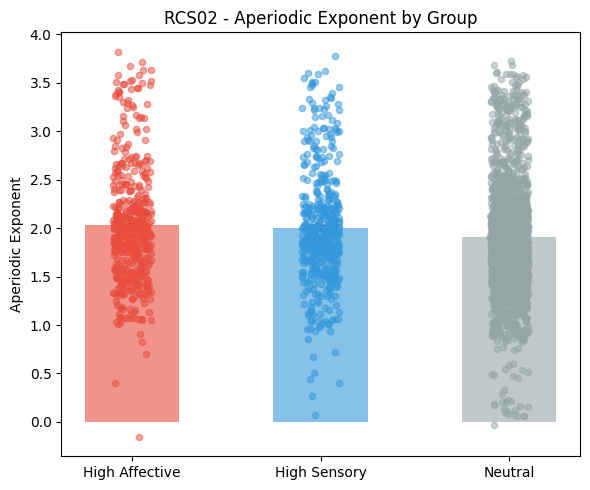

In [26]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))

groups = ['only_high_aff', 'only_high_sense', '']
colors = ['#E74C3C', '#3498DB', '#95A5A6']
labels = ['High Affective', 'High Sensory', 'Neutral']

for i, (grp, col, lab) in enumerate(zip(groups, colors, labels)):
    data = records_df[records_df['group'] == grp]['exponent'].dropna()
    
    # bar
    ax.bar(i, data.mean(), color=col, alpha=0.6, label=lab, width=0.5)
    ax.errorbar(i, data.mean(), yerr=data.sem(), color='black', capsize=4, lw=1.5)
    
    # scatter
    jitter = np.random.uniform(-0.1, 0.1, len(data))
    ax.scatter(np.full(len(data), i) + jitter, data, 
               color=col, alpha=0.5, s=20, zorder=3)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(labels)
ax.set_ylabel('Aperiodic Exponent')
ax.set_title(f'{ptID} - Aperiodic Exponent by Group')
plt.tight_layout()
plt.show()

In [34]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

group_data = {lab: records_df[records_df['group'] == grp]['exponent'].dropna().values
              for grp, lab in zip(groups, labels)}

stat, p_kruskal = kruskal(*group_data.values())
print(f"Kruskal-Wallis: H={stat:.3f}, p={p_kruskal:.4f}")

pairs = list(combinations(labels, 2))
print(f"\nPairwise Mann-Whitney (Bonferroni corrected, n_comparisons={len(pairs)}):")
for lab1, lab2 in pairs:
    u, p_raw = mannwhitneyu(group_data[lab1], group_data[lab2], alternative='two-sided')
    p_corrected = min(p_raw * len(pairs), 1.0)  # Bonferroni
    print(f"  {lab1} vs {lab2}: U={u:.1f}, p={p_raw:.4f}, p_corrected={p_corrected:.4f}")

Kruskal-Wallis: H=24.345, p=0.0000

Pairwise Mann-Whitney (Bonferroni corrected, n_comparisons=3):
  High Affective vs High Sensory: U=124829.0, p=0.5309, p_corrected=1.0000
  High Affective vs Neutral: U=578229.0, p=0.0000, p_corrected=0.0001
  High Sensory vs Neutral: U=566946.0, p=0.0007, p_corrected=0.0020


In [76]:
hypoth_labels = sorted(['ACC', 'MCC', 'AINS', 'PINS','THAL','dlPFC'])
hypoth_labels_bi = ['L '+nl for nl in hypoth_labels] + ['R '+ nl for nl in hypoth_labels]
affective_ch = []
for ch in hypoth_labels_bi:
    if ch in electrode_indices_by_ROI:
            affective_ch+=electrode_indices_by_ROI[ch]
            print(ch, affective_ch)

L AINS [103, 104, 102, 122]
L MCC [103, 104, 102, 122, 51, 48, 49]
L PINS [103, 104, 102, 122, 51, 48, 49, 101, 100, 116, 117, 118, 120, 121]
L dlPFC [103, 104, 102, 122, 51, 48, 49, 101, 100, 116, 117, 118, 120, 121, 28, 114, 113, 112, 27, 26]
R MCC [103, 104, 102, 122, 51, 48, 49, 101, 100, 116, 117, 118, 120, 121, 28, 114, 113, 112, 27, 26, 34, 33]
R THAL [103, 104, 102, 122, 51, 48, 49, 101, 100, 116, 117, 118, 120, 121, 28, 114, 113, 112, 27, 26, 34, 33, 70, 69, 68]


In [ ]:
# Aperiodic and periodic feature extraction
import pandas as pd
from fooof import FOOOF, FOOOFGroup
from fooof.bands import Bands
from fooof.analysis import get_band_peak_fm, get_band_peak_fg

# Initialize FOOOF group object for each trial
fg = FOOOFGroup(peak_width_limits=[1, 8], min_peak_height=0.1, max_n_peaks=6)
# Define frequency range across which to model the spectrum
freq_range = [3, 50] # Min frequency suggested to be twice the lowest recorded frequency to filter out noise
fg.fit(freqs_welch, np.array(list(psd_all_labeled.values())), freq_range) # new_freq and spectra data are required to be linearly spaced, spectra requires psd (no log)

# Extract aperiodic parameters
aps = fg.get_params('aperiodic_params')

# Extract peak parameters
peaks = fg.get_params('peak_params')

# Extract goodness-of-fit metrics
errors = fg.get_params('error') # Need an error threshold?
r2s = fg.get_params('r_squared')

# Save raw data of periodic and aperiodic features
pdf = pd.DataFrame(peaks, columns=['CF','PW','BW','Channel']) # Num peaks of all group/channel * 4
display(pdf)
pdf['Channel'] = pdf['Channel'].astype('int')
idx_to_label = {i: label for i, label in enumerate(psd_all_labeled.keys())}
pdf['Channel_label'] = pdf['Channel'].map(idx_to_label)

display(pdf)
apdf = pd.DataFrame(aps, columns=['Offset','Exp']) # Num group/channel * 2
apdf = pd.DataFrame(aps, columns=['Offset','Exp'])
apdf['Channel_label'] = list(psd_all_labeled.keys())
# pdf.to_csv("dir")
# apdf.to_csv("dir")

# Process periodic feature: extract peak in each canonical bandwith
bandref = Bands({'delta':[1,4], 
                 'theta':[4,8], 
                 'alpha':[8,12], 
                 'beta':[12,30], 
                 'low_gamma':[30,70], 
                 'high_gamma':[70,150]})
deltas = get_band_peak_fg(fg, bandref.delta) # Num group/channel * 3 (CF,PW,BW)
thetas = get_band_peak_fg(fg, bandref.theta)
alphas = get_band_peak_fg(fg, bandref.alpha)
betas = get_band_peak_fg(fg, bandref.beta)
low_gammas = get_band_peak_fg(fg, bandref.low_gamma)
high_gammas = get_band_peak_fg(fg, bandref.high_gamma)

# Design matrix: distribution of 'CF' (bar) and mean 'PW' across trial of certain HAMD/MPQ/intensity/xxx in individual patients
    # one for intensity score; one for mood vas score -- different in CF (checked for significant fit)
    # if CF nonsignificant, distribution of PW
    # one for aperiodic feature esp exponent

# Extract all fits that are above some error threshold, for further examination.
# error_threshold = 0.010
# to_check = []
# for ind, res in enumerate(fg):
#     fm = fg.get_fooof(ind, regenerate=True)
#     fm.plot()
#     print(fm.get_params('error'))



Running FOOOFGroup across 25 power spectra.


,CF,PW,BW,Channel
0,8.033007,0.850044,2.052262,0.0
1,10.414964,0.565910,2.828234,0.0
2,16.786726,0.266658,8.000000,0.0
3,21.940216,0.213556,1.000000,0.0
4,9.937443,0.660837,4.284866,1.0
...,...,...,...,...
116,8.804373,0.297280,2.303815,24.0
117,11.688096,0.197960,3.766165,24.0
118,20.033835,0.184040,5.713449,24.0
119,22.848646,0.142864,1.419870,24.0


,CF,PW,BW,Channel,Channel_label
0,8.033007,0.850044,2.052262,0,L AINS_1
1,10.414964,0.565910,2.828234,0,L AINS_1
2,16.786726,0.266658,8.000000,0,L AINS_1
3,21.940216,0.213556,1.000000,0,L AINS_1
4,9.937443,0.660837,4.284866,1,L AINS_2
...,...,...,...,...,...
116,8.804373,0.297280,2.303815,24,R THAL_3
117,11.688096,0.197960,3.766165,24,R THAL_3
118,20.033835,0.184040,5.713449,24,R THAL_3
119,22.848646,0.142864,1.419870,24,R THAL_3


In [110]:
apdf

,Offset,Exp,Channel_label
0,3.631753,2.310093,L AINS_1
1,3.005272,2.041630,L AINS_2
2,2.353800,1.768527,L AINS_3
3,3.156843,2.019898,L AINS_4
4,3.184545,2.126090,L MCC_1
5,6.460539,3.445484,L MCC_2
6,2.076941,1.570671,L MCC_3
7,2.985816,2.175534,L PINS_1
8,2.141337,1.634495,L PINS_2
9,2.673820,1.804569,L PINS_3
